<a href="https://colab.research.google.com/github/haniyathul/Praktikum-Analisis-Deret-Waktu/blob/main/Tugas%20Praktikum_STA2542_Minggu_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PRAKTIKUM 1 ANALISIS DERET WAKTU
# HANIYATHUL HUSNA (M0501251011)

In [1]:
#memanggil packages yang dibutuhkan
import numpy as np
import pandas as pd
import math
import random
import matplotlib.pyplot as plt
import seaborn as sns
import re
from google.colab import files

import warnings
warnings.filterwarnings("ignore")

## 1. Deret Curah Hujan Bogor

In [2]:
#memanggil data curah hujan yang tersimpan dalam github
rr=pd.read_csv('https://raw.githubusercontent.com/lailynissa/tsapython/refs/heads/main/curahhujan_agg.csv')

Pada tahap awal, data curah hujan dipanggil dari GitHub menggunakan fungsi pd.read_csv(). Data tersebut kemudian disimpan ke dalam objek rr.

In [3]:
#menampilkan 10 data pertama
rr.head(10)

,tanggal,rr
0,2007-01,12.025806
1,2007-02,15.650000
2,2007-03,8.916129
3,2007-04,15.756667
4,2007-05,6.309677
5,2007-06,9.116667
6,2007-07,4.319355
7,2007-08,7.996774
8,2007-09,6.863333
9,2007-10,7.596774


Berdasarkan hasil tersebut, data terdiri atas dua variabel, yaitu tanggal yang menunjukkan periode pengamatan dan rr yang menunjukkan nilai curah hujan.

In [4]:
rr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   tanggal  72 non-null     object 
 1   rr       72 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.3+ KB


Berdasarkan hasil rr.info(), diketahui bahwa data berbentuk DataFrame dengan 72 baris dan 2 kolom. Tidak terdapat data yang hilang karena kedua variabel memiliki 72 non-null.

tanggal memiliki tipe data object, sehingga

*   tanggal masih tersimpan dalam bentuk teks.
*   rr memiliki tipe data float64, yang menunjukkan bahwa nilai curah hujan berupa data numerik/desimal.

In [6]:
#mengubah tipe data menjadi datetime
rr.tanggal=pd.to_datetime(rr.tanggal)

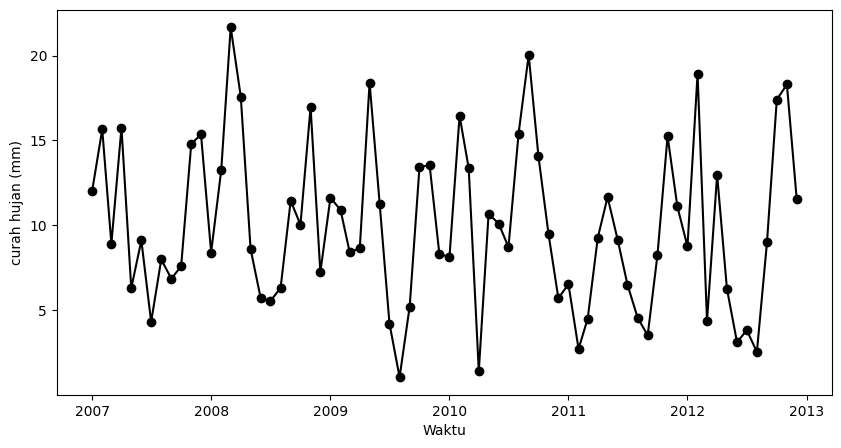

In [7]:
#menampilkan plot deret waktu dari data
plt.figure(figsize=(10,5))
plt.plot(rr.tanggal,rr.rr,'-ok')
plt.xlabel('Waktu'), plt.ylabel('curah hujan (mm)')
plt.show()

Dari plot ini dapat dilihat bahwa curah hujan Bogor cukup fluktuatif, karena nilainya sering mengalami kenaikan dan penurunan dari waktu ke waktu. Terlihat beberapa periode dengan curah hujan tinggi, bahkan mencapai sekitar 20-22 mm, tetapi kemudian turun kembali hingga sekitar 1-5 mm. Karena kenaikan dan penurunan tersebut terjadi berulang dan tidak bergerak ke satu arah tertentu, maka belum terlihat adanya tren naik atau tren turun yang konsisten

In [13]:
from statsmodels.tsa.stattools import adfuller

hasil_adf = adfuller(rr['rr'])

print('ADF Statistic:', hasil_adf[0])
print('p-value:', hasil_adf[1])

ADF Statistic: -5.540927969436175
p-value: 1.7024010193305273e-06


Berdasarkan uji Augmented Dickey-Fuller (ADF), diperoleh nilai ADF Statistic sebesar -5,5409 dengan p-value sebesar 0,0000017. Karena p-value < 0,05, maka $H_0$ ditolak. Dengan demikian, data curah hujan Bogor dapat dikatakan telah stasioner

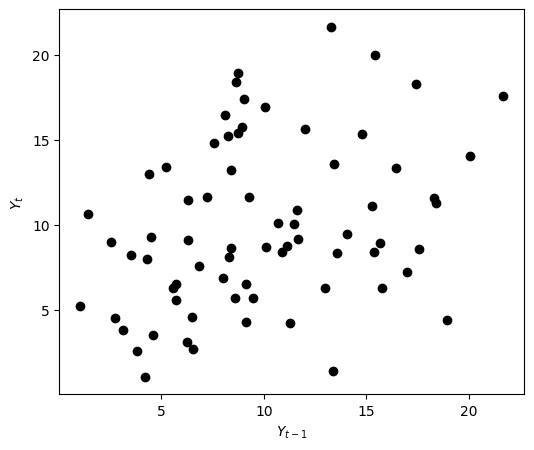

In [8]:
#menampilkan scatter plot antara Yt dan Yt-1
plt.figure(figsize=(6,5))
pd.plotting.lag_plot(rr.rr, lag=1, c='k')
plt.xlabel(r'$Y_{t-1}$'),plt.ylabel(r'$Y_{t}$')
plt.show()

Sumbu $X = Y_{t-1}$ -- curah hujan satu periode sebelumnya
Sumbu $Y = Y_t$ -- curah hujan pada periode sekarang

Setiap titik menunjukkan pasangan nilai antara curah hujan sekarang dan satu periode sebelumnya.

Dari scatterplot, titik-titik terlihat cukup menyebar dan tidak membentuk pola garis lurus yang jelas. Memang ada sedikit kecenderungan bahwa ketika $Y_{t-1}$ meningkat, $Y_t$ juga bisa meningkat, tetapi penyebarannya cukup besar.

Jadi, secara visual hubungan antara curah hujan pada periode sekarang $Y_t$ dengan curah hujan satu periode sebelumnya $Y_{t-1}$ terlihat relatif lemah.

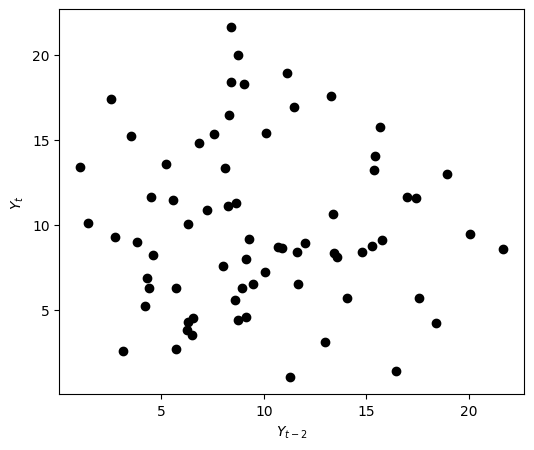

In [9]:
#menampilkan scatterplot antara Yt dan Yt-2
plt.figure(figsize=(6,5))
pd.plotting.lag_plot(rr.rr, lag=2, c='k')
plt.xlabel(r'$Y_{t-2}$'),plt.ylabel(r'$Y_{t}$')
plt.show()

Sumbu $X = Y_{t-2}$ -- curah hujan dua periode sebelumnya
Sumbu $Y = Y_t$ -- curah hujan pada periode sekarang
Setiap titik menunjukkan pasangan nilai curah hujan saat ini dengan nilai dua periode sebelumnya.

Dari scatterplot, titik-titik terlihat tersebar cukup luas dan tidak membentuk pola linear yang jelas. Nilai $Y_{t-2}$ yang rendah maupun tinggi dapat diikuti oleh nilai $Y_t$ yang rendah maupun tinggi.

Misalnya, pada $Y_{t-2}$ sekitar 8-10, nilai $Y_t$ tersebar dari sekitar 4 sampai lebih dari 20 mm. Ini menunjukkan bahwa nilai curah hujan dua periode sebelumnya tidak secara konsisten diikuti oleh nilai tertentu pada periode sekarang.

## 2. Deret Harga Saham BNI

In [10]:
#memanggil data harga saham BRI
bni=pd.read_csv('https://raw.githubusercontent.com/lailynissa/tsapython/refs/heads/main/BBNI.JK.csv')

In [11]:
bni.head(5)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2022-10-03,8975.0,9000.0,8825.0,8900.0,8900.0,14174700
1,2022-10-04,8925.0,9000.0,8850.0,8850.0,8850.0,29190100
2,2022-10-05,8900.0,8975.0,8850.0,8850.0,8850.0,32491500
3,2022-10-06,8900.0,8950.0,8800.0,8900.0,8900.0,11984500
4,2022-10-07,8850.0,8875.0,8750.0,8775.0,8775.0,18278000


In [12]:
#memeriksa tipe data
bni.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       59 non-null     object 
 1   Open       59 non-null     float64
 2   High       59 non-null     float64
 3   Low        59 non-null     float64
 4   Close      59 non-null     float64
 5   Adj Close  59 non-null     float64
 6   Volume     59 non-null     int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 3.4+ KB


In [14]:
#mengubah type data menjadi datetime
bni.Date=pd.to_datetime(bni.Date)

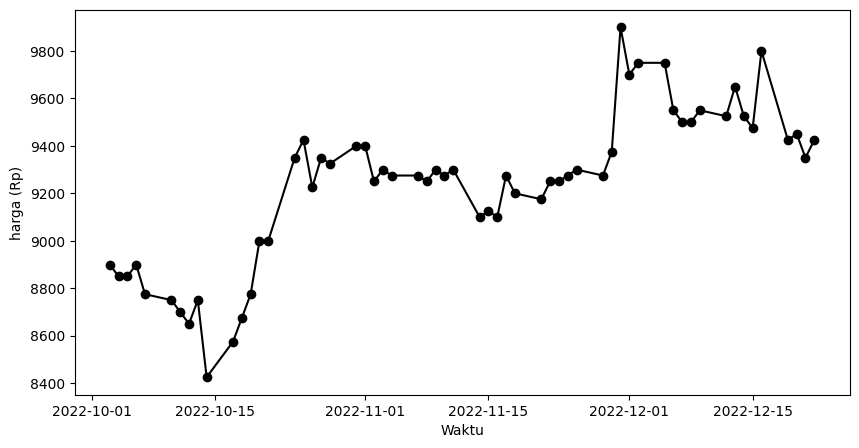

In [15]:
#menampilkan plot deret waktu
plt.figure(figsize=(10,5))
plt.plot(bni.Date,bni.Close,'-ok')
plt.xlabel('Waktu'), plt.ylabel('harga (Rp)')
plt.show()

Secara keseluruhan, harga saham BNI selama periode pengamatan menunjukkan pola yang cukup fluktuatif, tetapi cenderung mengalami peningkatan. Pada awal periode, harga saham berada pada kisaran Rp8.000-Rp9.000, kemudian mengalami beberapa kenaikan dan penurunan. Memasuki akhir periode, harga cenderung berada pada kisaran Rp9.000-Rp10.000. Hal ini menunjukkan adanya kecenderungan peningkatan harga saham meskipun pergerakannya tetap berfluktuasi dari waktu ke waktu.

In [16]:
from statsmodels.tsa.stattools import adfuller

hasil_adf = adfuller(bni['Close'])

print('ADF Statistic:', hasil_adf[0])
print('p-value:', hasil_adf[1])

ADF Statistic: -1.5122317024116863
p-value: 0.5274520466105076


“Berdasarkan uji ADF, diperoleh p-value sebesar 0,5275. Karena p-value lebih besar dari 0,05, maka H0 gagal ditolak. Artinya, data harga saham BNI pada level belum stasioner, sehingga perlu dilakukan differencing untuk memperoleh data yang stasioner.”

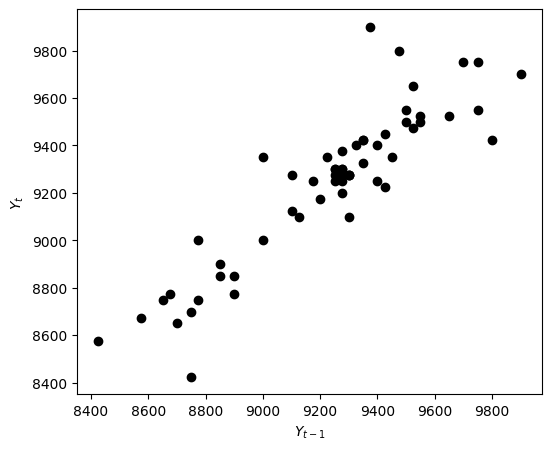

In [17]:
#menampilkan scatterplot antara Yt dan Yt-1
plt.figure(figsize=(6,5))
pd.plotting.lag_plot(bni.Close, lag=1, c='k')
plt.xlabel(r'$Y_{t-1}$'),plt.ylabel(r'$Y_{t}$')
plt.show()

$X = Y_t$ dan $Y=Y_{t-1}$
titik-titik cenderung membentuk pola linear dari kiri bawah ke kanan atas. Artinya, ketika nilai $Y_{t-1}$ meningkat, nilai $Y_t$ juga cenderung meningkat.

Penyebaran titik di sekitar pola tersebut juga relatif tidak terlalu jauh, sehingga menunjukkan adanya hubungan positif yang cukup kuat antara harga saham pada periode sekarang dengan harga saham satu periode sebelumnya.

$Y_t$ memiliki hubungan positif yang kuat dengan $Y_{t-1}$. Artinya, harga saham pada periode sekarang cenderung mengikuti atau berkaitan erat dengan harga saham pada periode sebelumnya.

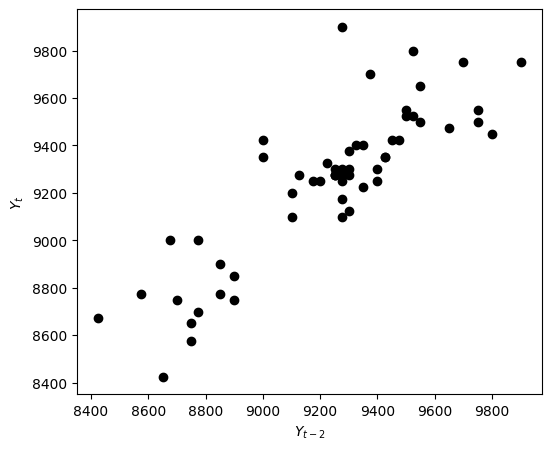

In [18]:
#menampilkan scatterplot antara Yt dan Yt-2
plt.figure(figsize=(6,5))
pd.plotting.lag_plot(bni.Close, lag=2, c='k')
plt.xlabel(r'$Y_{t-2}$'),plt.ylabel(r'$Y_{t}$')
plt.show()

$X = Y_t$ dan $Y=Y_{t-2}$ titik-titik juga menunjukkan pola meningkat dari kiri bawah ke kanan atas, sehingga terdapat hubungan positif antara $Y_t$ dan $Y_{t-2}$.

Namun, dibandingkan gambar pertama, titik-titik pada gambar kedua terlihat sedikit lebih menyebar dari pola linear. Artinya, hubungan $Y_t$ dengan harga saham dua periode sebelumnya masih positif, tetapi tidak sekuat hubungan pada lag 1.

Pada lag 2, $Y_t$ masih menunjukkan hubungan positif dengan $Y_{t-2}$, tetapi kekuatan hubungannya cenderung lebih rendah dibandingkan pada lag 1.

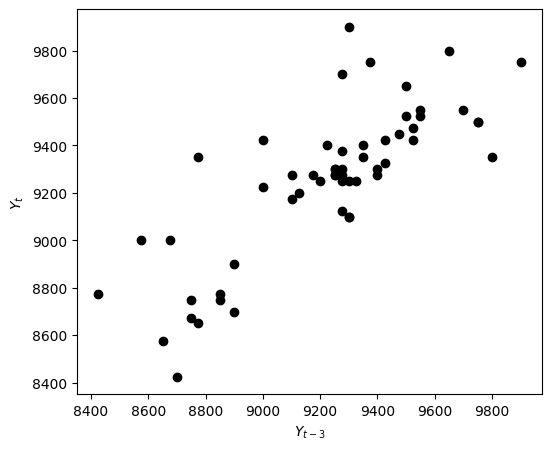

In [19]:
#menampilkan scatterplot antara Yt dan Yt-3
plt.figure(figsize=(6,5))
pd.plotting.lag_plot(bni.Close, lag=3, c='k')
plt.xlabel(r'$Y_{t-3}$'),plt.ylabel(r'$Y_{t}$')
plt.show()

$X = Y_t$ dan $Y=Y_{t-3}$ titik-titik masih terlihat cenderung membentuk pola linear positif, yaitu bergerak dari kiri bawah menuju kanan atas. Hal ini menunjukkan bahwa ketika nilai $Y_{t-3}$ meningkat, nilai $Y_t$ juga cenderung meningkat.

Namun, titik-titik mulai terlihat lebih menyebar dibandingkan pada lag 1. Artinya, hubungan antara harga saham pada periode sekarang dengan harga saham tiga periode sebelumnya masih terlihat positif, tetapi kekuatannya mulai berkurang.

Kesimpulannya, pada lag 3, hubungan antara $Y_t$ dan $Y_{t-3}$ masih menunjukkan pola positif. Namun, penyebaran titik yang semakin besar menunjukkan bahwa keterkaitan antara harga saham saat ini dengan harga saham tiga periode sebelumnya cenderung lebih lemah dibandingkan lag yang lebih pendek.

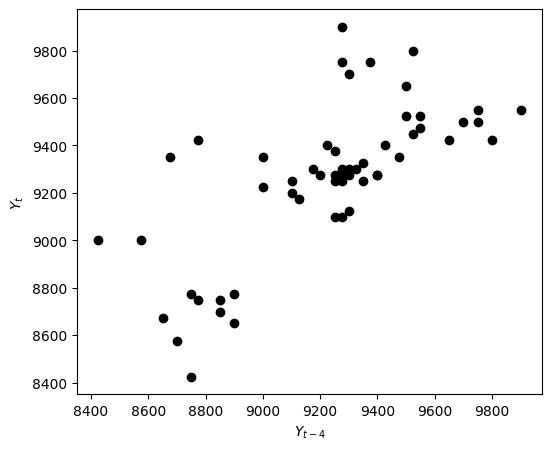

In [20]:
#menampilkan scatterplot antara Yt dan Yt-4
plt.figure(figsize=(6,5))
pd.plotting.lag_plot(bni.Close, lag=4, c='k')
plt.xlabel(r'$Y_{t-4}$'),plt.ylabel(r'$Y_{t}$')
plt.show()

$X = Y_t$ dan $Y=Y_{t-4}$ Pada gambar keempat, titik-titik juga masih menunjukkan kecenderungan pola linear positif. Ketika nilai $Y_{t-4}$ meningkat, nilai $Y_t$ cenderung ikut meningkat.

Akan tetapi, titik-titik terlihat cukup menyebar, terutama pada beberapa nilai $Y_{t-4}$, sehingga hubungan yang terbentuk tidak sekuat pola pada lag 1.

Pada lag 4, hubungan antara $Y_t$ dan $Y_{t-4}$ masih cenderung positif, tetapi penyebaran titik menunjukkan bahwa keterkaitannya semakin melemah. Hal ini mengindikasikan bahwa semakin jauh jarak waktu antara periode sekarang dan periode sebelumnya, hubungan harga saham cenderung semakin berkurang.

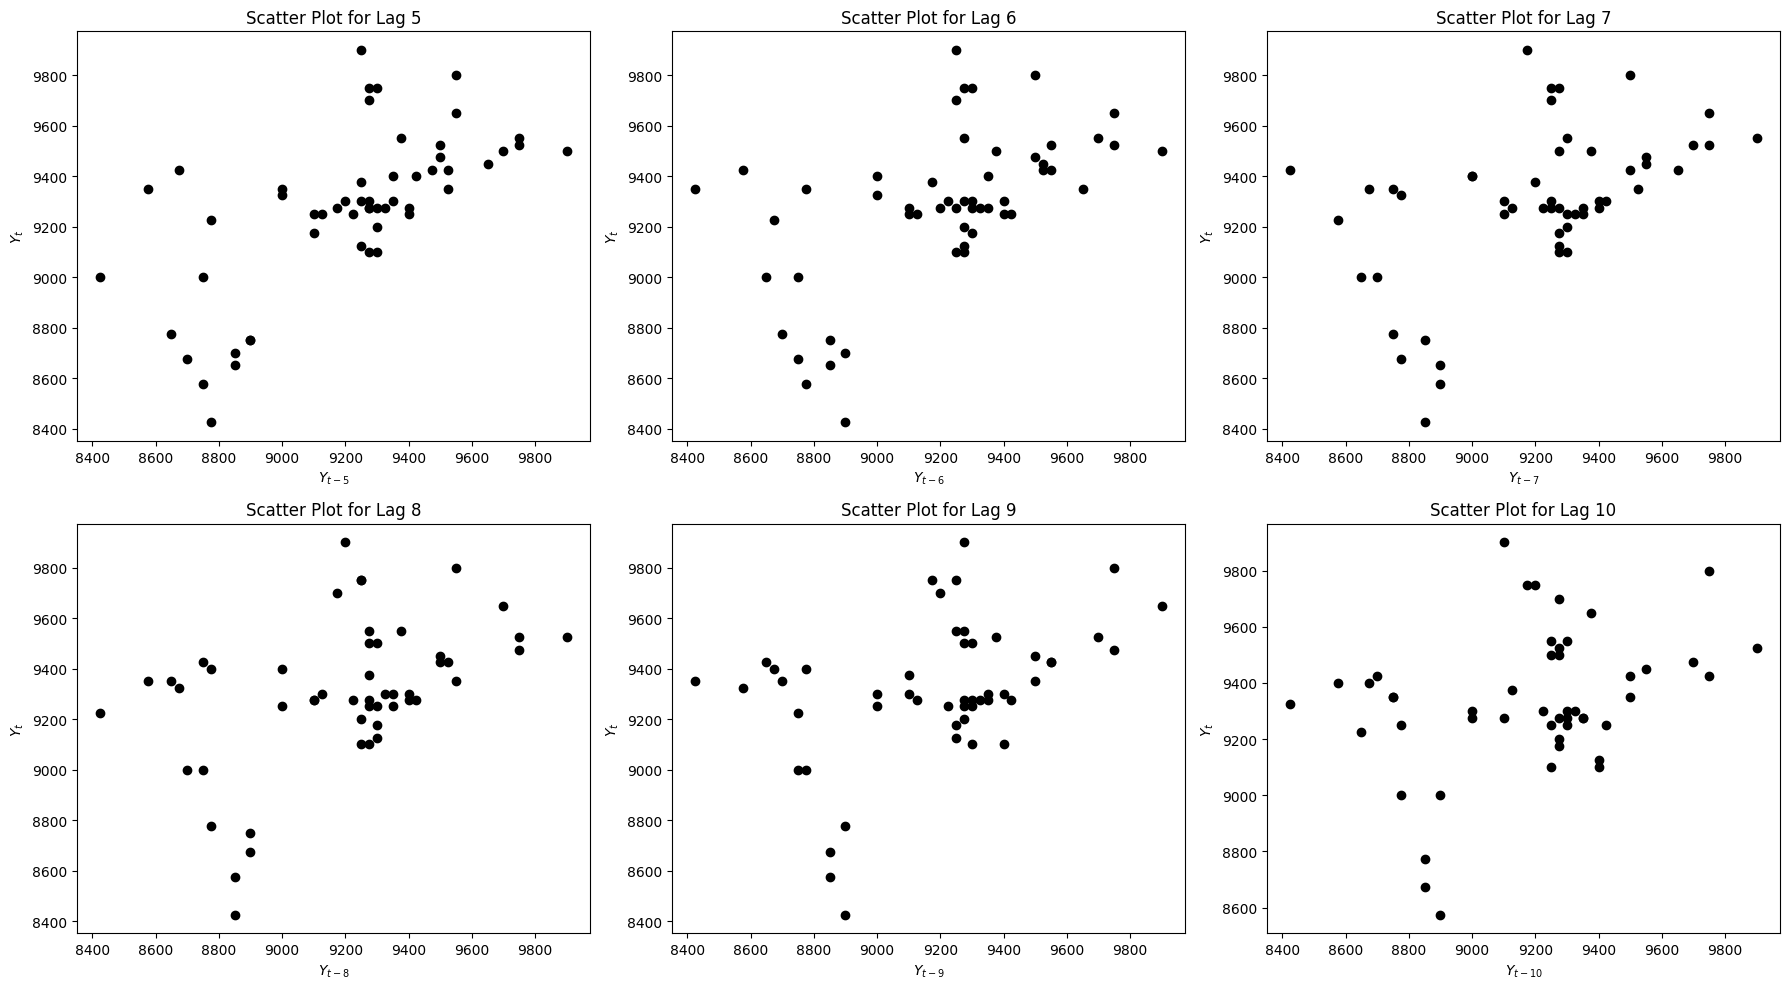

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

lags = range(5, 11)

for i, lag in enumerate(lags):
    ax = axes[i]
    pd.plotting.lag_plot(bni.Close, lag=lag, ax=ax, c='k')
    ax.set_xlabel(f'$Y_{{t-{lag}}}$')
    ax.set_ylabel(f'$Y_t$')
    ax.set_title(f'Scatter Plot for Lag {lag}')

plt.tight_layout()
plt.show()

Berdasarkan scatterplot $Y_t$ dengan lag 1 hingga lag 10, secara umum terlihat bahwa titik-titik masih menunjukkan kecenderungan hubungan positif antara $Y_t$ dengan nilai masa lalunya $Y_{t-k}$. Hal ini terlihat dari pola titik yang secara umum bergerak dari kiri bawah ke kanan atas pada sebagian besar lag.

Pada lag 1, pola hubungan positif terlihat paling jelas. Titik-titik relatif mengikuti pola linear, sehingga menunjukkan bahwa harga saham pada periode sekarang memiliki hubungan yang cukup kuat dengan harga saham satu periode sebelumnya.

Ketika lag bertambah menjadi lag 2, 3, dan 4, pola positif masih terlihat. Namun, titik-titik mulai mengalami penyebaran yang lebih besar, sehingga hubungan antara $Y_t$ dan $Y_{t-k}$ secara visual mulai berkurang dibandingkan lag 1.

Pada lag 5 hingga lag 10, pola hubungan positif masih dapat terlihat, tetapi titik-titik menjadi semakin menyebar dan pola linear semakin tidak jelas. Dengan kata lain, hubungan antara harga saham saat ini dengan harga saham pada periode yang semakin jauh sebelumnya cenderung semakin lemah.